            DISCRETE-EVENT MODEL TRACE LOG (VERIFICATION ACTIVE)
[TIME:  1.57 min] | Event: Customer 1   Arrived      | Queue Length: 0 | Server: FREE
[TIME:  1.57 min] | Event: Customer 1   Started      | Queue Length: 0 | Server: BUSY
[TIME:  2.22 min] | Event: Customer 2   Arrived      | Queue Length: 0 | Server: BUSY
[TIME:  4.57 min] | Event: Customer 1   Departed     | Queue Length: 1 | Server: FREE
[TIME:  4.57 min] | Event: Customer 2   Started      | Queue Length: 0 | Server: BUSY
[TIME:  6.43 min] | Event: Customer 3   Arrived      | Queue Length: 0 | Server: BUSY
[TIME:  6.73 min] | Event: Customer 4   Arrived      | Queue Length: 1 | Server: BUSY
[TIME:  7.57 min] | Event: Customer 2   Departed     | Queue Length: 2 | Server: FREE
[TIME:  7.57 min] | Event: Customer 3   Started      | Queue Length: 1 | Server: BUSY
[TIME:  9.80 min] | Event: Customer 5   Arrived      | Queue Length: 1 | Server: BUSY
[TIME: 10.57 min] | Event: Customer 3   Departed     | Queue Length: 2 | Se

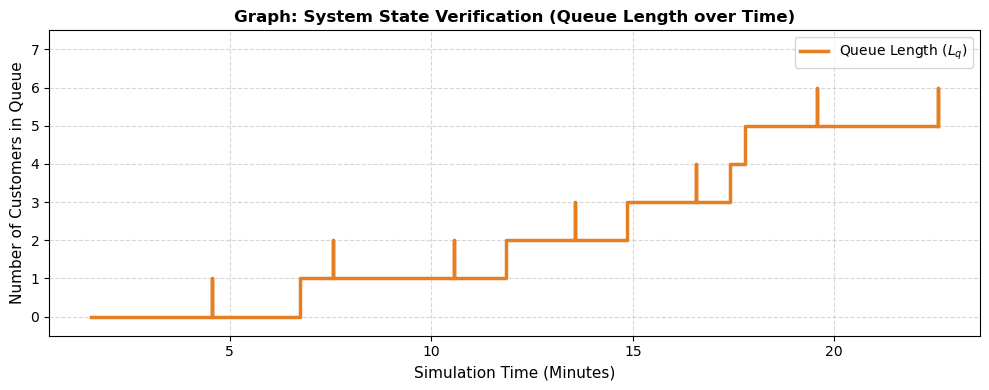

In [8]:
import random
import simpy
import matplotlib.pyplot as plt

# --- ১. প্যারামিটার এবং গ্লোবাল ভ্যারিয়েবল ---
SIM_TIME = 25
RANDOM_SEED = 7
ARRIVAL_RATE = 4.0   # গড়ে প্রতি ৪ মিনিটে ১ জন আসবে
SERVICE_TIME = 3.0   # সার্ভিস দিতে ৩ মিনিট লাগবে

trace_time = []
trace_queue = []

# গাণিতিক ভেরিফিকেশনের জন্য সার্ভারের ব্যস্ত সময় ট্র্যাক করার ভ্যারিয়েবল
total_busy_time = 0.0
last_server_change_time = 0.0
server_was_busy = False

def trace_logger(env, name, action, q_len, server_status):
    """প্রতিটি ইভেন্টের লাইভ স্টেট লগ করার ফাংশন"""
    global total_busy_time, last_server_change_time, server_was_busy
    
    current_time = env.now
    
    # সার্ভার যদি আগে থেকেই ব্যস্ত থাকে, তবে এই ইভেন্ট পর্যন্ত তার ব্যস্ত সময় যোগ হবে
    if server_was_busy:
        total_busy_time += (current_time - last_server_change_time)
        
    # বর্তমান ইভেন্টের পর সার্ভার ব্যস্ত নাকি ফ্রি তা আপডেট করা
    server_was_busy = (server_status == "BUSY")
    last_server_change_time = current_time

    print(f"[TIME: {current_time:5.2f} min] | Event: Customer {name:<3} {action:<12} | Queue Length: {q_len} | Server: {server_status}")
    trace_time.append(current_time)
    trace_queue.append(q_len)

def customer(env, name, cashier):
    # কাস্টমারের আগমন
    trace_logger(env, name, "Arrived", len(cashier.queue), "BUSY" if cashier.count > 0 else "FREE")
    
    with cashier.request() as request:
        yield request
        # সার্ভিস শুরু
        trace_logger(env, name, "Started", len(cashier.queue), "BUSY")
        
        yield env.timeout(SERVICE_TIME)
        # সার্ভিস শেষ ও প্রস্থান
        trace_logger(env, name, "Departed", len(cashier.queue), "BUSY" if cashier.count > 1 else "FREE")

def customer_generator(env, cashier):
    c_id = 1
    while True:
        yield env.timeout(random.expovariate(1.0 / ARRIVAL_RATE))
        env.process(customer(env, str(c_id), cashier))
        c_id += 1

# --- ২. সিমুলেশন রান এবং লাইভ ট্রেস প্রিন্ট ---
print("=" * 80)
print("            DISCRETE-EVENT MODEL TRACE LOG (VERIFICATION ACTIVE)")
print("=" * 80)

random.seed(RANDOM_SEED)
env = simpy.Environment()
cashier = simpy.Resource(env, capacity=1)

env.process(customer_generator(env, cashier))
env.run(until=SIM_TIME)

# সিমুলেশন শেষ হওয়ার মুহূর্তে যদি সার্ভার ব্যস্ত থাকে, সেই শেষ অংশটুকু যোগ করা
if server_was_busy:
    total_busy_time += (SIM_TIME - last_server_change_time)

print("=" * 80)

# --- ৩. গাণিতিক ভেরিফিকেশন রিপোর্ট (Conservation Law) ---
total_idle_time = SIM_TIME - total_busy_time
calculated_total_time = total_busy_time + total_idle_time

print("\n" + "="*50)
print("       MATHEMATICAL VERIFICATION REPORT")
print("="*50)
print(f"1. Total Simulated Time : {SIM_TIME:.2f} min")
print(f"2. Total Busy Time (Server): {total_busy_time:.2f} min")
print(f"3. Total Idle Time (Server): {total_idle_time:.2f} min")
print("-"*50)
print(f"Verification Check (Busy + Idle) = {calculated_total_time:.2f} min")

# ফ্লোটিং পয়েন্টের সূক্ষ্ম পার্থক্য এড়ানোর জন্য round করা হয়েছে
if round(calculated_total_time, 4) == round(SIM_TIME, 4):
    print("STATUS: VERIFICATION SUCCESSFUL (Logic Holds True) ✅")
else:
    print("STATUS: VERIFICATION FAILED (Logic Broken) ❌")
print("="*50)

# --- ৪. গ্রাফ প্রদর্শন (State Verification Graph) ---
plt.figure(figsize=(10, 4))
plt.step(trace_time, trace_queue, where='post', color='#e67e22', linewidth=2.5, label='Queue Length ($L_q$)')
plt.title("Graph: System State Verification (Queue Length over Time)", fontsize=12, fontweight='bold')
plt.xlabel("Simulation Time (Minutes)", fontsize=11)
plt.ylabel("Number of Customers in Queue", fontsize=11)
plt.ylim(-0.5, max(trace_queue) + 1.5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()